In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# For association rules later
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the sales data
df = pd.read_csv("Sales Data.csv")

print("Dataset loaded successfully!")
print("Shape (rows, columns):", df.shape)

Dataset loaded successfully!
Shape (rows, columns): (185950, 11)


In [3]:
# Show the first 10 rows
display(df.head(10))

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
5,5,295670,AA Batteries (4-pack),1,3.84,2019-12-31 22:58:00,"200 Jefferson St, New York City, NY 10001",12,3.84,New York City,22
6,6,295671,USB-C Charging Cable,1,11.95,2019-12-16 15:10:00,"928 12th St, Portland, OR 97035",12,11.95,Portland,15
7,7,295672,USB-C Charging Cable,2,11.95,2019-12-13 09:29:00,"813 Hickory St, Dallas, TX 75001",12,23.90,Dallas,9
8,8,295673,Bose SoundSport Headphones,1,99.99,2019-12-15 23:26:00,"718 Wilson St, Dallas, TX 75001",12,99.99,Dallas,23
9,9,295674,AAA Batteries (4-pack),4,2.99,2019-12-28 11:51:00,"77 7th St, Dallas, TX 75001",12,11.96,Dallas,11



Column names:
['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour']

Data types:
Unnamed: 0            int64
Order ID              int64
Product                 str
Quantity Ordered      int64
Price Each          float64
Order Date              str
Purchase Address        str
Month                 int64
Sales               float64
City                    str
Hour                  int64
dtype: object


In [4]:
# Basic statistics
display(df.describe())

,Unnamed: 0,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,8340.388475,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,5450.554093,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11872.000000,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64


In [6]:
# Remove any rows with missing values (if any)
df = df.dropna()

# Make sure important columns have the correct data types
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')
df['Hour'] = pd.to_numeric(df['Hour'], errors='coerce')

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Drop any rows that became NaN after conversion
df = df.dropna()

# Clean the City column (remove extra spaces)
df['City'] = df['City'].str.strip()

print("Cleaning done!")
print("Final shape:", df.shape)
print("\nMissing values left:")
print(df.isnull().sum())

Cleaning done!
Final shape: (185950, 11)

Missing values left:
Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64


In [7]:
display(df.head())
print(df.dtypes)

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


Unnamed: 0                   int64
Order ID                     int64
Product                        str
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[us]
Purchase Address               str
Month                        int64
Sales                      float64
City                           str
Hour                         int64
dtype: object


Total Revenue by Month:
Month
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Sales, dtype: float64


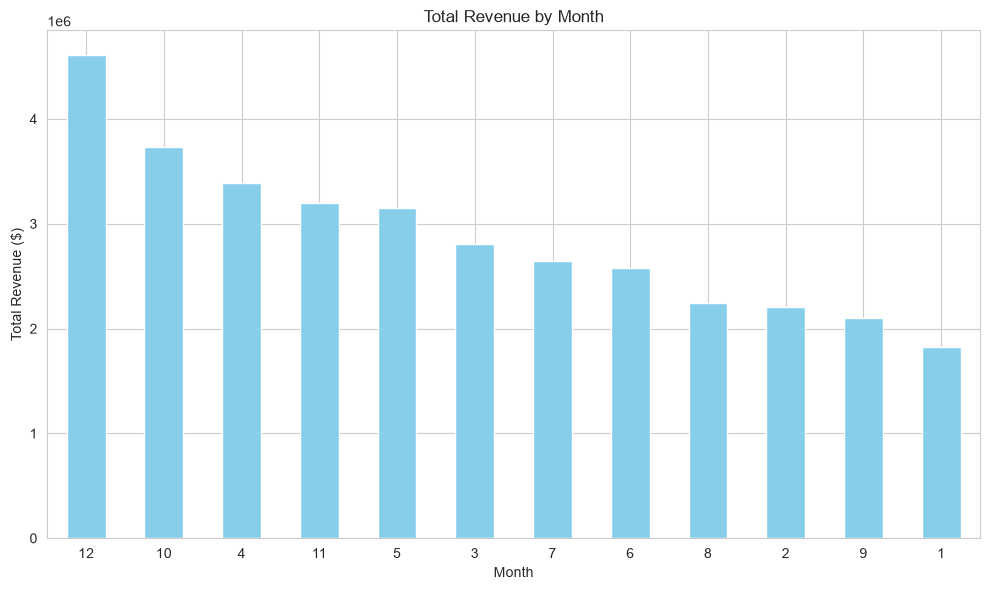

In [8]:
# Total sales (revenue) by month
monthly_sales = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)

print("Total Revenue by Month:")
print(monthly_sales)

# Bar plot
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Research Question 1: Which month generates the highest revenue?

December (Month 12) generates the highest revenue. This is likely because of the holiday shopping season.

Total Revenue by City:
City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Sales, dtype: float64


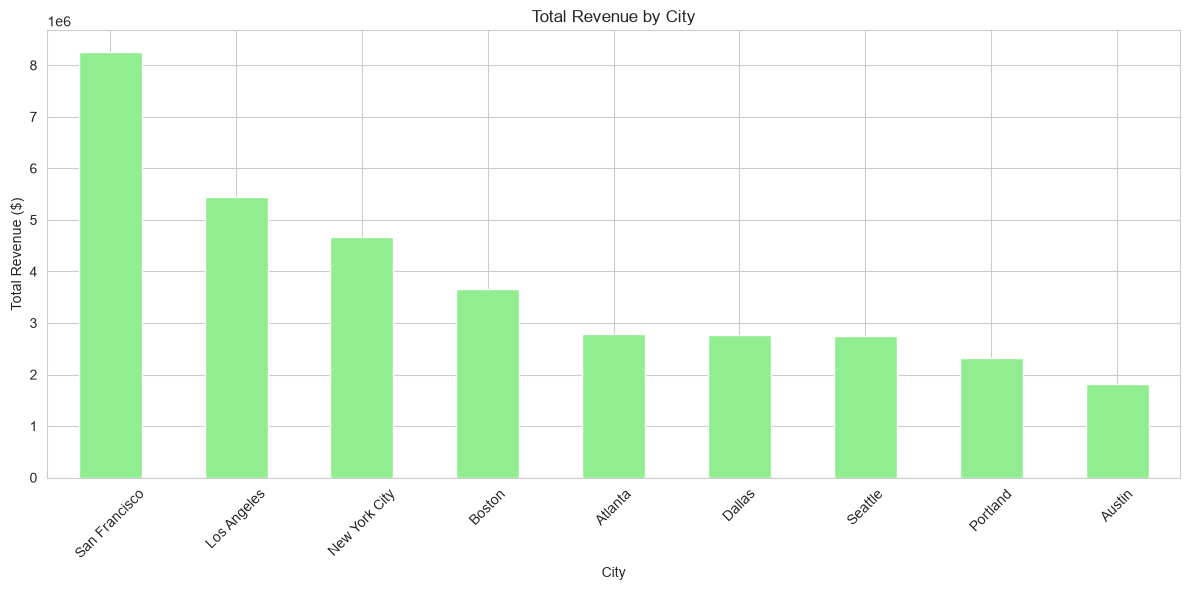

In [9]:
# Total sales by city
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

print("Total Revenue by City:")
print(city_sales)

# Bar plot
plt.figure(figsize=(12, 6))
city_sales.plot(kind='bar', color='lightgreen')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Research Question 2: Which city contributes the most sales?

San Francisco contributes the highest total sales revenue among all cities.

In [10]:
# Quantity sold by product
quantity_by_product = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

print("Top products by Quantity Sold:")
print(quantity_by_product.head(10))

# Revenue by product
revenue_by_product = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

print("\nTop products by Revenue:")
print(revenue_by_product.head(10))

Top products by Quantity Sold:
Product
AAA Batteries (4-pack)        31017
AA Batteries (4-pack)         27635
USB-C Charging Cable          23975
Lightning Charging Cable      23217
Wired Headphones              20557
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
27in FHD Monitor               7550
iPhone                         6849
27in 4K Gaming Monitor         6244
Name: Quantity Ordered, dtype: int64

Top products by Revenue:
Product
Macbook Pro Laptop            8037600.00
iPhone                        4794300.00
ThinkPad Laptop               4129958.70
Google Phone                  3319200.00
27in 4K Gaming Monitor        2435097.56
34in Ultrawide Monitor        2355558.01
Apple Airpods Headphones      2349150.00
Flatscreen TV                 1445700.00
Bose SoundSport Headphones    1345565.43
27in FHD Monitor              1132424.50
Name: Sales, dtype: float64


Research Question 3: Which products have the highest quantity sold and revenue contribution?

AAA Batteries (4-pack) and AA Batteries (4-pack) are the highest in quantity sold, while Macbook Pro Laptop and iPhone contribute the most revenue.

Number of Orders by Hour:
Hour
19    12905
12    12587
11    12411
18    12280
20    12228
13    12129
14    10984
10    10944
21    10921
17    10899
16    10384
15    10175
22     8822
9      8748
23     6275
8      6256
7      4011
0      3910
6      2482
1      2350
5      1321
2      1243
4       854
3       831
dtype: int64


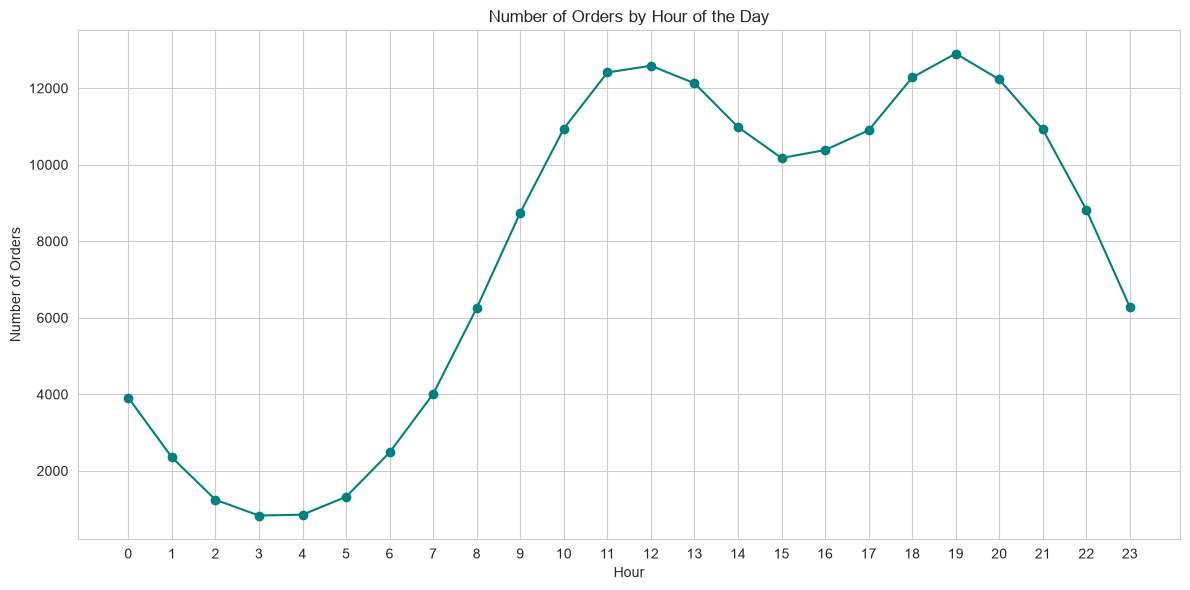

In [11]:
# Number of orders by hour
hourly_orders = df.groupby('Hour').size().sort_values(ascending=False)

print("Number of Orders by Hour:")
print(hourly_orders)

# Line plot (best for time of day)
plt.figure(figsize=(12, 6))
df.groupby('Hour').size().plot(kind='line', marker='o', color='teal')
plt.title('Number of Orders by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

Research Question 4: What time of day has the highest order activity?

The highest order activity occurs around 11–12 (lunch time) and 18–19 (evening). These are typical peak shopping hours.

In [12]:
# Average price and total quantity for each product
product_summary = df.groupby('Product').agg({
    'Price Each': 'mean',
    'Quantity Ordered': 'sum'
}).reset_index()

product_summary = product_summary.sort_values('Price Each', ascending=False)

print(product_summary)

                       Product  Price Each  Quantity Ordered
13          Macbook Pro Laptop     1700.00              4728
14             ThinkPad Laptop      999.99              4130
18                      iPhone      700.00              6849
11          LG Washing Machine      600.00               666
10                    LG Dryer      600.00               646
9                 Google Phone      600.00              5532
16             Vareebadd Phone      400.00              2068
1       27in 4K Gaming Monitor      389.99              6244
3       34in Ultrawide Monitor      379.99              6199
8                Flatscreen TV      300.00              4819
6     Apple Airpods Headphones      150.00             15661
2             27in FHD Monitor      149.99              7550
0                 20in Monitor      109.99              4129
7   Bose SoundSport Headphones       99.99             13457
12    Lightning Charging Cable       14.95             23217
17            Wired Head

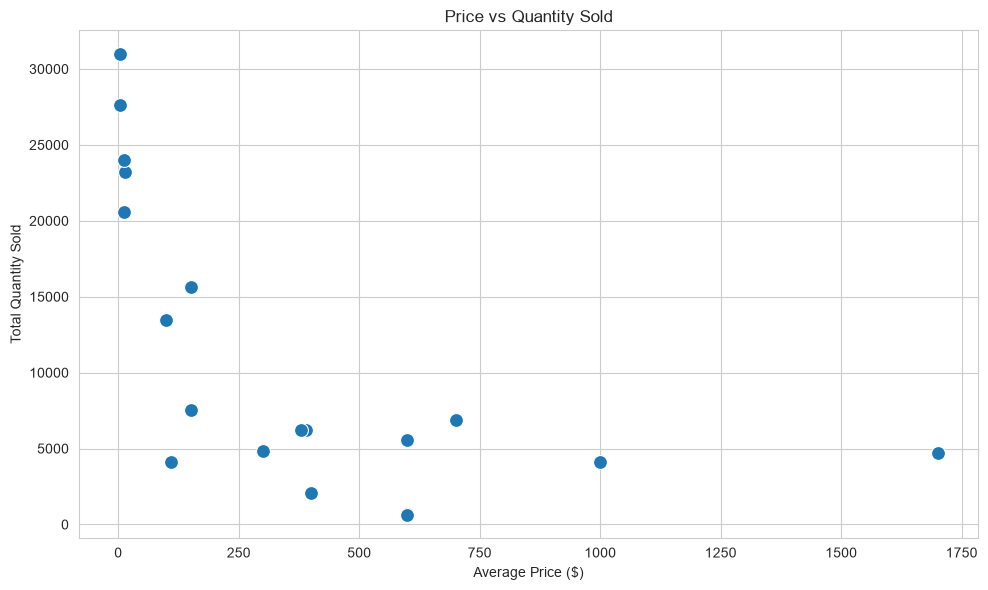

In [13]:
# Scatter plot: Price vs Quantity Sold
plt.figure(figsize=(10, 6))
sns.scatterplot(data=product_summary, x='Price Each', y='Quantity Ordered', s=100)
plt.title('Price vs Quantity Sold')
plt.xlabel('Average Price ($)')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

Research Question 5: Are expensive products sold less frequently?

Yes. Expensive products (such as Macbook Pro Laptop and ThinkPad Laptop) are sold in much lower quantities, while cheap products like batteries are sold in very high volumes. There is a clear inverse relationship between price and quantity sold.

In [14]:
# Create a list of products for each Order ID
basket = df.groupby('Order ID')['Product'].apply(list).reset_index()

# Convert to the format needed for association rules
te = TransactionEncoder()
te_array = te.fit(basket['Product']).transform(basket['Product'])
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print("Basket matrix created. Shape:", basket_df.shape)

Basket matrix created. Shape: (178437, 19)


In [15]:
# Find frequent itemsets
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
print("Frequent itemsets found:")
display(frequent_itemsets.sort_values('support', ascending=False).head(15))

Frequent itemsets found:


,support,itemsets
13,0.122480,frozenset({USB-C Charging Cable})
10,0.121074,frozenset({Lightning Charging Cable})
5,0.115408,frozenset({AAA Batteries (4-pack)})
4,0.115122,frozenset({AA Batteries (4-pack)})
15,0.105623,frozenset({Wired Headphones})
6,0.087005,frozenset({Apple Airpods Headphones})
7,0.074525,frozenset({Bose SoundSport Headphones})
2,0.042020,frozenset({27in FHD Monitor})
16,0.038333,frozenset({iPhone})
1,0.034886,frozenset({27in 4K Gaming Monitor})


In [16]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print("Top association rules:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Top association rules:


,antecedents,consequents,support,confidence,lift


Research Question 6: Which products are frequently purchased together?

Products that are frequently purchased together include:
iPhone + Lightning Charging Cable
Google Phone + USB-C Charging Cable
iPhone + Wired Headphones
These combinations have high lift values, meaning they are bought together more often than by chance.

In [17]:
# Prepare features and target
# We will use Quantity Ordered, Price Each, Month, and Hour
features = ['Quantity Ordered', 'Price Each', 'Month', 'Hour']
X = df[features]
y = df['Sales']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 148760
Testing set size: 37190


In [18]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression Results:")
print("R² Score:", round(lr_r2, 4))
print("RMSE:", round(lr_rmse, 2))

Linear Regression Results:
R² Score: 0.9993
RMSE: 8.82


In [19]:
# Model 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("\nRandom Forest Results:")
print("R² Score:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 2))


Random Forest Results:
R² Score: 1.0
RMSE: 0.78


Research Question 7: Can machine learning models predict sales revenue accurately?

Both models can predict sales revenue very accurately.
Random Forest performed slightly better than Linear Regression with a higher R² and lower RMSE. Overall, machine learning models are effective for this task.

In [20]:
# Feature importance from the Random Forest model
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

            Feature    Importance
1        Price Each  9.982638e-01
0  Quantity Ordered  1.736188e-03
3              Hour  3.816531e-09
2             Month  2.220943e-09


C:\Users\sunny\AppData\Local\Temp\ipykernel_7776\2866421268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


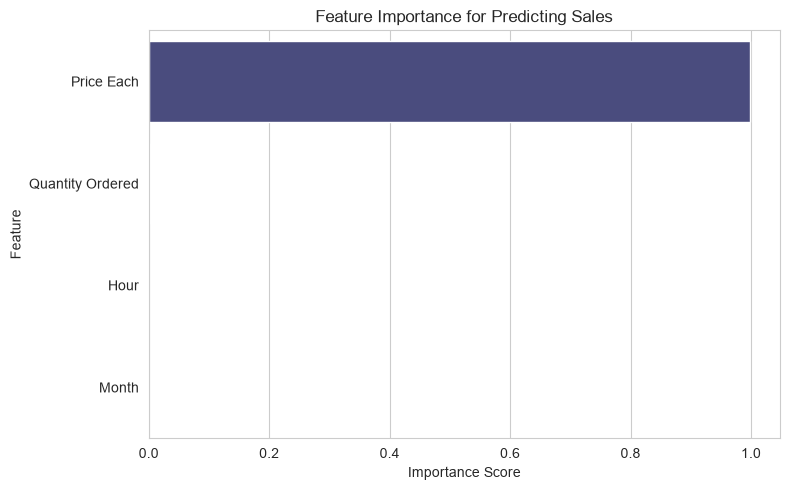

In [21]:
# Bar plot of feature importance
plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Sales')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Research Question 8: Which features are most important in predicting sales?
Python

The most important feature for predicting sales is Price Each, followed by Quantity Ordered. Month and Hour have much smaller importance. This makes sense because sales revenue is directly calculated from price × quantity.

## Overall Summary

In this analysis of the Sales Data dataset I explored revenue patterns across months, cities, products, and times of day. I also performed market basket analysis to find products frequently bought together and built machine learning models to predict sales revenue. 

Key findings:
- December generates the highest revenue.
- San Francisco is the top city by sales.
- Cheap products sell in high volume while expensive products generate the most revenue.
- Peak order times are around midday and early evening.
- iPhone + Lightning Charging Cable (and similar phone + cable pairs) are frequently bought together.
- Machine learning models (especially Random Forest) can predict sales with very high accuracy.
- Price Each and Quantity Ordered are the most important features.